
# 1. LOAD DATASET

In [1]:


import pandas as pd

# Load dataset

df = pd.read_csv("C:\\End-to-End_Logistic_Regression\\student_data_set.csv")

# Display first 5 rows

df.head()

,Hours_Studied,Attendance,Assignments,Sleep_Hours,Previous_Marks,Internet_Usage_Hours,Extracurricular_Activities,Mock_Test_Score,Final_Marks
0,1,57.0,41.0,9.0,54,2,0,7,70
1,9,61.0,73.0,3.0,40,3,2,9,84
2,12,55.0,50.0,3.0,75,2,4,7,87
3,1,NaN,87.0,4.0,25,2,5,3,43
4,1,58.0,NaN,10.0,53,8,0,5,62


# 2. UNDERSTAND THE DATA

In [2]:
# Shape of dataset

print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(103, 9)


In [3]:
# Column names

print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Hours_Studied', 'Attendance', 'Assignments', 'Sleep_Hours',
       'Previous_Marks', 'Internet_Usage_Hours', 'Extracurricular_Activities',
       'Mock_Test_Score', 'Final_Marks'],
      dtype='object')


In [4]:
# Dataset information

print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               103 non-null    int64  
 1   Attendance                  98 non-null     float64
 2   Assignments                 98 non-null     float64
 3   Sleep_Hours                 98 non-null     float64
 4   Previous_Marks              103 non-null    int64  
 5   Internet_Usage_Hours        103 non-null    int64  
 6   Extracurricular_Activities  103 non-null    int64  
 7   Mock_Test_Score             103 non-null    int64  
 8   Final_Marks                 103 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 7.4 KB
None


In [5]:
#Statistical summary

print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Hours_Studied  Attendance  Assignments  Sleep_Hours  Previous_Marks  \
count     103.000000   98.000000    98.000000    98.000000      103.000000   
mean        6.805825   74.224490    61.510204     6.438776       59.048544   
std         5.475540   29.228757    21.715710     2.315641       22.918174   
min         1.000000   40.000000    30.000000     3.000000       20.000000   
25%         4.000000   57.000000    41.000000     4.000000       36.000000   
50%         6.000000   73.500000    57.000000     6.500000       63.000000   
75%         9.000000   88.000000    81.750000     9.000000       78.500000   
max        50.000000  300.000000   100.000000    10.000000       95.000000   

       Internet_Usage_Hours  Extracurricular_Activities  Mock_Test_Score  \
count            103.000000                  103.000000       103.000000   
mean               5.679612                    2.631068         5.116505   
std                3.375847                    

In [6]:
# Duplicate rows

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
3


# 3. VISUALIZE THE DATA

In [7]:
# Import matplotlib
import matplotlib.pyplot as plt

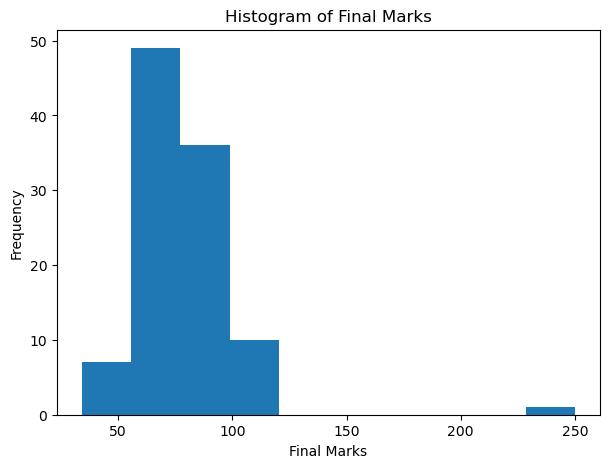

In [8]:
# Histogram for Final Marks

plt.figure(figsize=(7,5))
plt.hist(df["Final_Marks"], bins=10)
plt.title("Histogram of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Frequency")
plt.show()

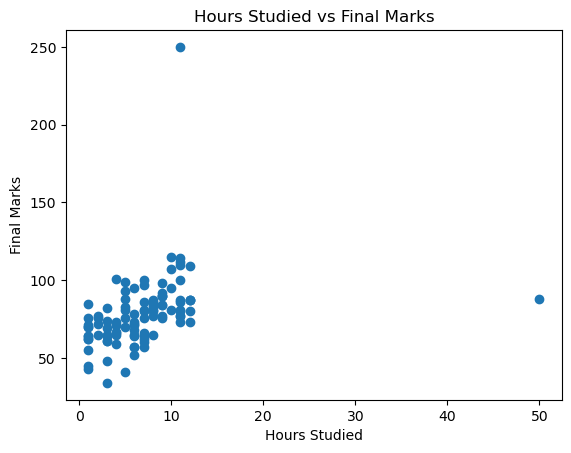

In [9]:
# Scatter plot
plt.scatter(df["Hours_Studied"], df["Final_Marks"])
plt.xlabel("Hours Studied")
plt.ylabel("Final Marks")
plt.title("Hours Studied vs Final Marks")
plt.show()

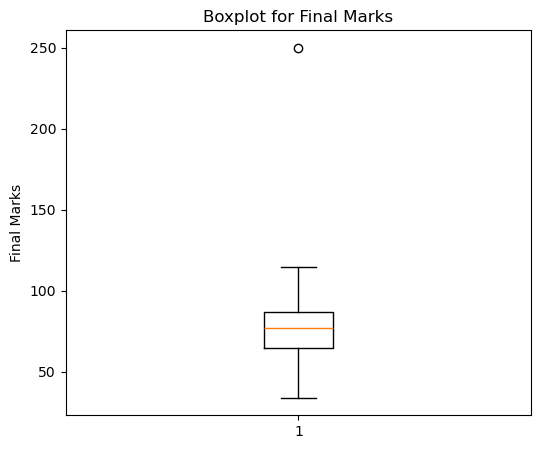

In [10]:
# Single Boxplot

plt.figure(figsize=(6,5))
plt.boxplot(df["Final_Marks"])
plt.title("Boxplot for Final Marks")
plt.ylabel("Final Marks")
plt.show()

# 4. FIND NULL VALUES AND HANDLE NULL VALUES

In [11]:
# Fill null values using mean
df = df.fillna(df.mean(numeric_only=True))
# Check again
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Assignments                   0
Sleep_Hours                   0
Previous_Marks                0
Internet_Usage_Hours          0
Extracurricular_Activities    0
Mock_Test_Score               0
Final_Marks                   0
dtype: int64


In [12]:
# Fill null values using mean
df = df.fillna(df.mean(numeric_only=True))
# Check again
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Assignments                   0
Sleep_Hours                   0
Previous_Marks                0
Internet_Usage_Hours          0
Extracurricular_Activities    0
Mock_Test_Score               0
Final_Marks                   0
dtype: int64


# 5. REMOVE DUPLICATE ROWS

In [13]:

print("Duplicates Before Removing:")
print(df.duplicated().sum())

Duplicates Before Removing:
3


In [14]:
# Remove duplicates

df = df.drop_duplicates()
print("Duplicates After Removing:")
print(df.duplicated().sum())

Duplicates After Removing:
0


In [15]:
# Check null values again

print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Assignments                   0
Sleep_Hours                   0
Previous_Marks                0
Internet_Usage_Hours          0
Extracurricular_Activities    0
Mock_Test_Score               0
Final_Marks                   0
dtype: int64


In [16]:
# Fill all missing values

df = df.fillna(df.mean(numeric_only=True))

# Check again

print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Assignments                   0
Sleep_Hours                   0
Previous_Marks                0
Internet_Usage_Hours          0
Extracurricular_Activities    0
Mock_Test_Score               0
Final_Marks                   0
dtype: int64


# 6. FIND OUTLIERS

In [17]:
# Import matplotlib

import matplotlib.pyplot as plt

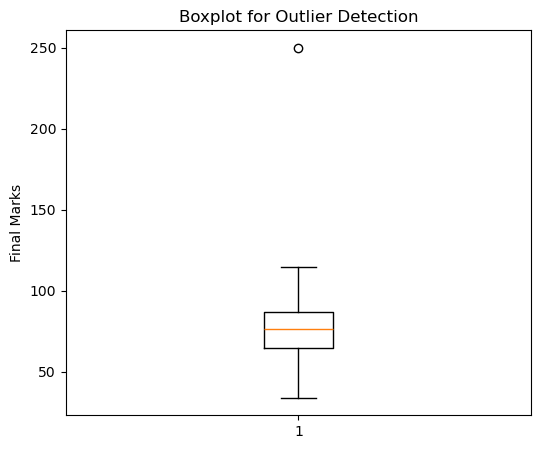

In [18]:

# 6. FIND OUTLIERS

# Boxplot for detecting outliers
plt.figure(figsize=(6,5))
plt.boxplot(df["Final_Marks"])
plt.title("Boxplot for Outlier Detection")
plt.ylabel("Final Marks")
plt.show()


# 7. HANDLE OUTLIERS USING IQR METHOD

In [19]:


# Import numpy

import numpy as np

In [20]:
# Calculate Q1, Q3 and IQR

Q1 = df["Final_Marks"].quantile(0.25)
Q3 = df["Final_Marks"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 65.0
Q3: 87.0
IQR: 22.0


In [21]:
# Find lower limit and upper limit

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 32.0
Upper Limit: 120.0


In [22]:
# Handle outliers
df["Final_Marks"] = np.where(
    df["Final_Marks"] < lower_limit,
    lower_limit,
    df["Final_Marks"]
)
df["Final_Marks"] = np.where(
    df["Final_Marks"] > upper_limit,
    upper_limit,
    df["Final_Marks"]
)
print("Outliers handled successfully")

Outliers handled successfully


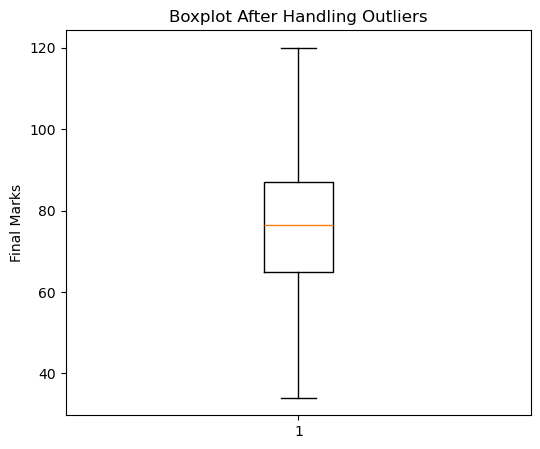

In [23]:
# Boxplot after handling outliers

plt.figure(figsize=(6,5))
plt.boxplot(df["Final_Marks"])
plt.title("Boxplot After Handling Outliers")
plt.ylabel("Final Marks")
plt.show()

# 8. FEATURE SCALING & FEATURE ENGINEERING

In [24]:
# Create new feature

df["Study_Efficiency"] = (
    df["Final_Marks"] / df["Hours_Studied"]
)
# Display dataset

df.head()

,Hours_Studied,Attendance,Assignments,Sleep_Hours,Previous_Marks,Internet_Usage_Hours,Extracurricular_Activities,Mock_Test_Score,Final_Marks,Study_Efficiency
0,1,57.00000,41.000000,9.0,54,2,0,7,70.0,70.000000
1,9,61.00000,73.000000,3.0,40,3,2,9,84.0,9.333333
2,12,55.00000,50.000000,3.0,75,2,4,7,87.0,7.250000
3,1,74.22449,87.000000,4.0,25,2,5,3,43.0,43.000000
4,1,58.00000,61.510204,10.0,53,8,0,5,62.0,62.000000


# 9. SEPARATE INPUT FEATURES AND TARGET

In [25]:
# Input features

X = df.drop("Final_Marks", axis=1)
# Target variable
y = df["Final_Marks"]
print(X.head())
print(y.head())

   Hours_Studied  Attendance  Assignments  Sleep_Hours  Previous_Marks  \
0              1    57.00000    41.000000          9.0              54   
1              9    61.00000    73.000000          3.0              40   
2             12    55.00000    50.000000          3.0              75   
3              1    74.22449    87.000000          4.0              25   
4              1    58.00000    61.510204         10.0              53   

   Internet_Usage_Hours  Extracurricular_Activities  Mock_Test_Score  \
0                     2                           0                7   
1                     3                           2                9   
2                     2                           4                7   
3                     2                           5                3   
4                     8                           0                5   

   Study_Efficiency  
0         70.000000  
1          9.333333  
2          7.250000  
3         43.000000  
4         62

# 10. DIVIDE DATA INTO TRAINING AND TESTING

In [26]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [27]:
# Divide dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (80, 9)
X_test Shape: (20, 9)


# 11. FEATURE SCALING

In [28]:
from sklearn.preprocessing import StandardScaler
# Apply scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature Scaling Completed")

Feature Scaling Completed


# 12. CREATE MODEL AND TRAIN MODEL

In [29]:
from sklearn.linear_model import LinearRegression
# Separate input and target

X = df.drop("Final_Marks", axis=1)

y = df["Final_Marks"]

In [30]:
# Train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
# Feature scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Train model

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Model Trained Successfully")

Model Trained Successfully


# 13. TEST THE MODEL

In [33]:
y_pred = model.predict(X_test_scaled)
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[ 86.17646091  74.27119736  63.62072137  84.24803168  83.32885592
  66.64081902  63.36709276  82.4680633  206.21902765  70.80157678]


# 14. COMPARE ACTUAL AND PREDICTED VALUES

In [34]:

result = pd.DataFrame({
    "Actual Final Marks": y_test.values,
    "Predicted Final Marks": y_pred
})

result.head(10)

,Actual Final Marks,Predicted Final Marks
0,95.0,86.176461
1,73.0,74.271197
2,64.0,63.620721
3,90.0,84.248032
4,80.0,83.328856
5,70.0,66.640819
6,65.0,63.367093
7,95.0,82.468063
8,88.0,206.219028
9,70.0,70.801577


# 15. PREDICT NEW DATA

In [35]:


new_student = [[
    8,     # Hours_Studied
    90,    # Attendance
    80,    # Assignments
    7,     # Sleep_Hours
    75,    # Previous_Marks
    3,     # Internet_Usage_Hours
    2,     # Extracurricular_Activities
    8,     # Mock_Test_Score
    10     # Study_Efficiency
]]

# Scale new data

new_student_scaled = scaler.transform(new_student)

# Predict

prediction = model.predict(new_student_scaled)

print("Predicted Final Marks:")

print(prediction[0])

Predicted Final Marks:
103.63747726713814


c:\Users\harika reddy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# 16. EVALUATION METRICS

In [36]:
# Import metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import numpy

import numpy as np

In [37]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 13.299004537924537
Mean Squared Error: 849.9515104136219
Root Mean Squared Error: 29.15392787282053
R2 Score: -4.385319481165334


# 17. DISPLAY ACTUAL VS PREDICTED VALUES

In [38]:
result = pd.DataFrame({
    "Actual Values": y_test.values,
    "Predicted Values": y_pred
})

print(result.head(10))

   Actual Values  Predicted Values
0           95.0         86.176461
1           73.0         74.271197
2           64.0         63.620721
3           90.0         84.248032
4           80.0         83.328856
5           70.0         66.640819
6           65.0         63.367093
7           95.0         82.468063
8           88.0        206.219028
9           70.0         70.801577


# 18. VISUALIZE ACTUAL VS PREDICTED VALUES

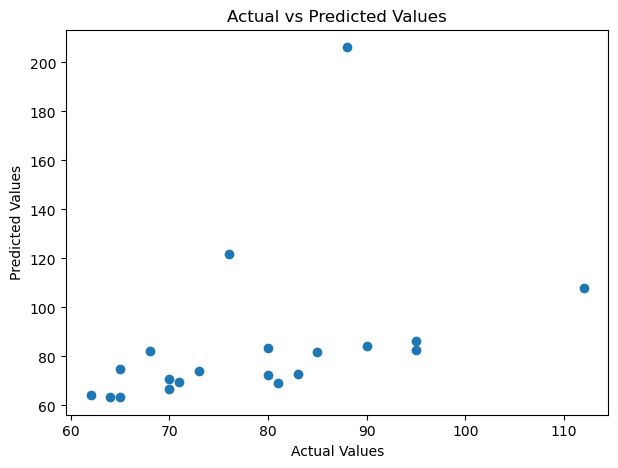

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

# 19. SAVE THE TRAINED MODEL

In [40]:
import pickle

In [41]:
# Save model into file

pickle.dump(model, open("student_model.pkl", "wb"))
print("Model Saved Successfully")

Model Saved Successfully


# 20. LOAD THE SAVED MODEL

In [42]:

# Load saved model

loaded_model = pickle.load(open("student_model.pkl", "rb"))
print("Model Loaded Successfully")

Model Loaded Successfully


# 21. PREDICT USING SAVED MODEL

In [43]:
prediction = loaded_model.predict(new_student_scaled)
print("Predicted Final Marks Using Saved Model:")
print(prediction[0])

Predicted Final Marks Using Saved Model:
103.63747726713814
